# Анализ Фурье аналоговых (непрерывных) сигналов

Сигнал первого типа:

$x_1(t) = (a_1 + b_1|t - t_1|)\,\cos(2\pi w_1 t)\,\chi_{[c_1,d_1]}(t)$

с константами:
$a_1 = 4,  b_1 = -0.1,  t_1 = 3,  w_1 = 2,  c_1 = 1,  d_1 = 9.$

Таким образом:

$x(t) = \bigl(4 - 0.1|t-3|\bigr)\cos(4\pi t),\quad t\in[1,9],\quad x(t)=0\;\text{вне этого отрезка}.$


In [4]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Анализ сигнала

Сигнал $x(t)$:

- **Финитный** – сигнал существует только на конечном промежутке времени [1,9], в других местах 0.
- **Кусочно-непрерывный** – на интервале (1,9) функция непрерывна, но на концах отрезка терпит разрыв первого рода:  
  $x(1)=3.8$, $x(1^-)=0$; аналогично на правом конце.
- **Кусочно-гладкая** – производная существует всюду, кроме точки t=3 (излом из-за модуля) и точек разрыва на границах.

**Принадлежность пространствам**  
- $L_1(\mathbb{R})$: $\int |x(t)|dt$ конечен, т.к. функция ограничена и финитна.  
- $L_2(\mathbb{R})$: аналогично.  
- $(\mathcal{S})$ – не принадлежит, так как не является бесконечно дифференцируемой (есть разрывы функции и излом).

**Свойства преобразования Фурье** $\hat{x}(\lambda)$  
- Так как $x(t)$ финитна, её преобразование Фурье - спектр будет размазан (сосредоточен) около 2Гц, т.к. полоса частот шире - спектр непрерывный и бесконечный.
- Из-за скачков на концах - высокие частоты, поэтому спектр убывает медленно.  
- Наличие внутри излома (t=3) - тоже даёт вклад в спектр - высокие частоты, но не такие как при скачке.


### 2. Построение графиков сигнала

Для чуть более полного понимания сигнала построим его на двух разных наборах параметров дискретизации:

1 вариант – мелкая сетка, чтобы увидеть более менее точную форму;
2 вариант – крупнее, чтобы увидеть, как влияет количество точек.

(берём интервалы чуть побольше, чтобы увидеть где сигнал затухает)

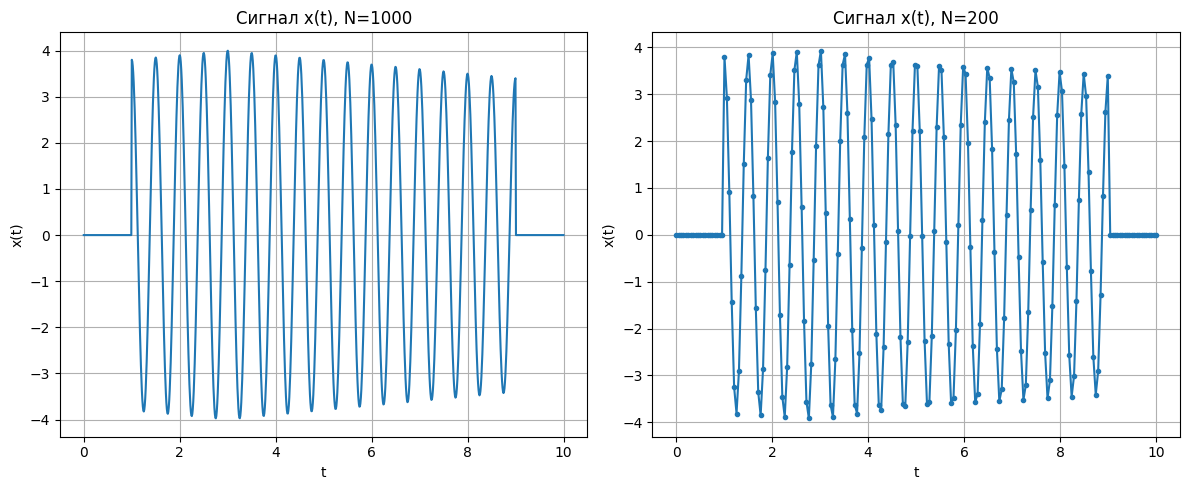

In [5]:
# В отдельную функцию сам сигнал - так удобнее
def signal(t,a1=4,b1=-0.1,t1=3,w1=2,c1=1,d1=9):
    # Характеристическая функция интервала [c1,d1]
    mask=(t>=c1)&(t<=d1)
    x=np.zeros_like(t)
    # Только там, где мы в интервале(маска true), вычисляем
    x[mask]=(a1+b1*np.abs(t[mask]-t1))*np.cos(2*np.pi*w1*t[mask])
    return x


t_min=0
t_max=10

# 1 - мелкая сетка
N1=1000
t1_vals=np.linspace(t_min,t_max,N1)
x1_vals=signal(t1_vals)

# 2 - крупная сетка
N2=200
t2_vals=np.linspace(t_min,t_max,N2)
x2_vals=signal(t2_vals)

# Строим
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(t1_vals,x1_vals)
plt.title(f"Сигнал x(t), N={N1}")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(t2_vals,x2_vals,"o-",markersize=3)
plt.title(f"Сигнал x(t), N={N2}")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)

plt.tight_layout()
plt.show()

*Анализ*:
- Колебания - косинусоида с частотой 2Гц (0.5 сек).
- Изменение амплитуды - от 3.8 до 4, потом до 3.4  - соответствует линейной функции.
- Излом у t=3.
- С большим N - сигнал гладкий, а с меньшим - ломаный.

### 3. Спектральный анализ. Прямое вычисление преобразования Фурье (ПФ)

Для вычисления FT используем аппроксимацию интеграла формулой прямоугольников из теории.  
Сигнал конечный, поэтому можно взять $t_{\min}=c_1=1, t_{\max}=d_1=9$. Тогда $\|x-x_1\|=0$ и условие точности выполняется автоматически (0<эпсилон).

**Параметры**:
- $t_{\min}=1, t_{\max}=9$
- Два значения $N$: 50 и 500
- Число точек разбиения $M = 2000$ (по заданию)
- Выбор $\lambda_{\min},\lambda_{\max}$ так, чтобы интервал по частоте был **больше периода ДПФ** $1/a$ (по заданию, чтобы период ДПФ - дискретного преобразования Фурье - меньше макс-мин)
(где $a = (t_{\max}-t_{\min})/N$ – шаг дискретизации)

#### Для N=50
- $a = (9-1)/50 = 0.16$
- Период ДПФ: $1/a = 6.25$
- Выберем $\lambda_{\min}=-10, \lambda_{\max}=10$ (ширина 20 > 6.25)
- Шаг дискретизации по частоте: $s = (20)/2000 = 0.01$

#### Для N=500
- $a = 8/500 = 0.016$
- Период ДПФ: $1/a = 62.5$
- Выберем $\lambda_{\min}=-100, \lambda_{\max}=100$ (ширина 200 > 62.5)
- Шаг дискретизации по частоте: $s = 200/2000 = 0.1$

Для вычисления ПФ в точках (для многих частот сразу) $\lambda_k = \lambda_{\min} + s k$ используем матричную форму равенства:

$$\hat{x}_1(\lambda_k) \approx a \sum_{n=0}^{N-1} x(t_n) e^{-2\pi i t_n \lambda_k},\quad t_n = t_{\min}+a n.$$

В коде такое удобно реализовать через скалярное произведение (или через умножение матрицы на вектор). Для оценки числа операций можно использовать теоретическое значение: $N\cdot M$ комплексных умножений и сложений. (в Python `flops` нет, поэтому просто сравню с теоретической оценкой)

In [6]:
# Функция для вычисления FT по формуле прямоугольников
# Возвращает она массив значений FT в точках lamda_k
def forward_ft(x,t_min,a,lamda_min,lamda_max,M):
    """
    x - массив значений сигнала длины N
    """
    N=len(x)
    lamda_vals=np.linspace(lamda_min,lamda_max,M,endpoint=False)
    s=(lamda_max-lamda_min)/M
    # Создаём матрицу A: (N,M) с элементами exp(-2*pi*i*t_n*lamda_k)
    t_n=t_min+a*np.arange(N)
    # broadcasting (N,1)*(1,M)->(N,M)
    A=np.exp(-2j * np.pi * np.outer(t_n, lamda_vals))
    ft=a*np.dot(x,A) # а результат размером M
    return lamda_vals, ft

t_min=1
t_max=9
M=2000

# Параметры для N=50
N1=50
a1=(t_max-t_min)/N1
t1=np.linspace(t_min,t_max,N1,endpoint=False)
x1=signal(t1)

lamda_min1, lamda_max1=-10,10
l1, ft1=forward_ft(x1,t_min,a1,lamda_min1,lamda_max1,M)

# Параметры для N=500
N2=500
a2=(t_max-t_min)/N2
t2=np.linspace(t_min,t_max,N2,endpoint=False)
x2=signal(t2)

lamda_min2, lamda_max2=-100,100
l2, ft2=forward_ft(x2,t_min,a2,lamda_min2,lamda_max2,M)

Графики для визуализации:

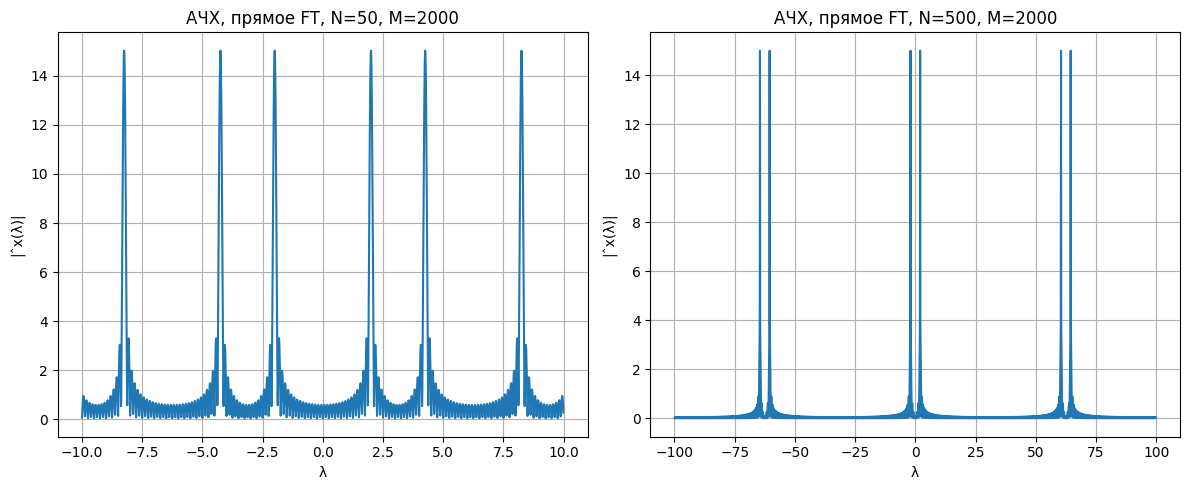

N=50, M=2000: теор. число операций ~ 1.00e+05
N=500, M=2000: теор. число операций ~ 1.00e+06


In [7]:
# Построение АЧХ (модуль FT)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(l1,np.abs(ft1))
plt.title(f"АЧХ, прямое FT, N={N1}, M={M}")
plt.xlabel("λ")
plt.ylabel("|ˆx(λ)|")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(l2,np.abs(ft2))
plt.title(f"АЧХ, прямое FT, N={N2}, M={M}")
plt.xlabel("λ")
plt.ylabel("|ˆx(λ)|")
plt.grid(True)

plt.tight_layout()
plt.show()

# Сколько операций
print(f"N={N1}, M={M}: теор. число операций ~ {N1*M:.2e}")
print(f"N={N2}, M={M}: теор. число операций ~ {N2*M:.2e}")

*Анализ*:
- При N=50 шаг дискретизации a=0.16 - крупный шаг - грубая дискретизация сигнала.
    * Спектр получается искажённым из-за эффекта наложения(aliasing) - высокие частоты кажутся низкими, так как шаг по времени недостаточно мал, чтобы правильно показать быстрые колебания.
    * Форма пиков размыта, но амлитуда не занижена - $\hat{x}(2)| \approx \frac{A \cdot T}{2} = \frac{3.8 \cdot 8}{2} = 15.2$.
    * Копии пиков на $\lambda = \pm 2 + k \cdot 6.25,\quad k \in \mathbb{Z}$ -(+-8.25;+-4.25;+-2)
    Основной пик на частоте 2 Гц - частота косинусоиды, а размазывается он из-за ограниченности во времени - финитности - появляются вот эти частоты вокруг основной.

- При N=500 шаг дискретизации a=0.016 - значительно меньший шаг - точнее сигнал.
    * Эффекта наложения практически нет.
    * Период ДПФ 62.5Гц - опять умещается несколько пиков, но они менее искажены.
    * Очень гладкий - близкий к истинному спектру.
- Огромные вычислительные затраты O(NM)
- Грубая/редкая сетка приводит к искажению спектра!

### 4. Спектральный анализ с использованием БПФ

Для ускорения вычислений используем алгоритм БПФ (быстрое вычисление ДПФ). Основная идея – связать дискретные отсчёты сигнала с его ДПФ так, чтобы шаг по частоте $s$ удовлетворял условию $N a s = 1$.  
Выберем $t_{\min}=1, t_{\max}=9$, $N=500$ (как в ДПФ). Тогда:
- $a = 0.016$
- $s = 1/(t_{\max}-t_{\min}) = 0.125$
- Период БПФ (интервал однозначного представления) равен $1/a = 62.5$.

Задание требует взять $\lambda_{\min}=0$ и подобрать $\lambda_{\max}$ так, чтобы период БПФ был **меньше** $(\lambda_{\max}-\lambda_{\min})$. Для этого нужно расширить интервал анализа по частоте, добавив нули к сигналу (zero-padding - сглаживаем график, а также помогаем исполнить условие периода БПФ). Возьмём количество точек БПФ $N_{\text{fft}} = 2048$ (степень двойки для эффективности - рекурсивность и деление задачи на 2, можно было и 1024 - тогда $\lambda_{\max}=(1024-1)*0.125=127.9>62.5$). Тогда шаг по частоте останется $s = 0.125$, а максимальная частота $\lambda_{\max} = (N_{\text{fft}}-1)s \approx 255.875$. Интервал $[0, 255.9]$ значительно больше периода 62.5 - условие выполнено.

Вычисление (по разделу "Спектральный анализ сигналов"):
- Создаём массив отсчётов сигнала длины $N$ на $[1,9]$.
- Дополняем его нулями до длины $N_{\text{fft}}$.
- Применяем `np.fft.fft`.
- Умножаем результат на $a$ (шаг по времени) и на множитель $e^{-2\pi i t_{\min}\lambda}$ для коррекции сдвига по времени (по формуле (1) в теории). В стандартном использовании `fft` без дополнительных множителей мы получаем ДПФ от последовательности, начиная с $t=0$. Чтобы учесть $t_{\min}$, нужно применить формулу:
  
  $$\hat{x}_1(\lambda_k) \approx a\, e^{-2\pi i t_{\min}\lambda_k} \cdot \text{FFT}\bigl[x(t_n) e^{-2\pi i \lambda_{\min} a n}\bigr]_k,$$
  
  где $\lambda_k = \lambda_{\min} + k s$. При $\lambda_{\min}=0$ множитель $e^{-2\pi i \lambda_{\min} a n}=1$. Тогда остаётся только множитель $e^{-2\pi i t_{\min}\lambda_k}$.


In [8]:
N=500
t_min=1
t_max=9
t=np.linspace(t_min,t_max,N,endpoint=False)
a=(t_max-t_min)/N
x=signal(t)

# Параметры для БПФ
N_fft=2048
lamda_min=0.0
# Шаг по частоте
s=1/(t_max-t_min)
lamda_max=(N_fft-1)*s

# Дополнение нулями
x_full=np.zeros(N_fft,dtype=complex)
x_full[:N]=x

# Вычисляем БПФ
# результат получается в порядке возрастания частоты от 0 до (N_fft-1)*s
X_fft=np.fft.fft(x_full)

# Коррекция фазы из-за нулевого t_min
freq = np.fft.fftfreq(N_fft, d=a)
correction=np.exp(-2j*np.pi*t_min*freq)
X_right=a*X_fft*correction

Графики для визуализации:

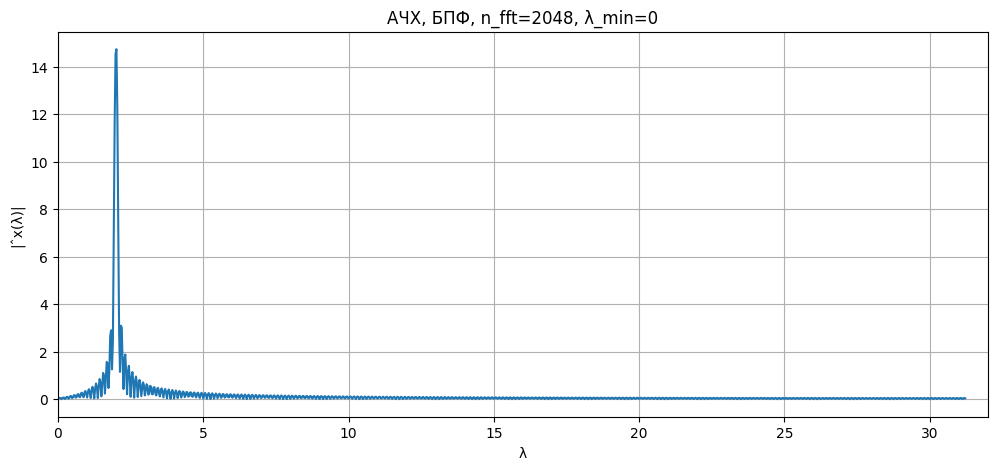

БПФ: N_fft=2048, теор. число операций ~ 2.25e+04
По сравнению с первым методом N=500, M=2000: 1.00e+06


In [9]:
# АЧХ
# беру только первые N_fft/2 точек, потому что остальные отображение отриц. частот
half=N_fft//2
l_plot=freq[:half]
amp_spectrum=np.abs(X_right[:half])

plt.figure(figsize=(12,5))
plt.plot(l_plot,amp_spectrum)
plt.title(f"АЧХ, БПФ, n_fft={N_fft}, λ_min=0")
plt.xlabel("λ")
plt.ylabel("|ˆx(λ)|")
plt.grid(True)
plt.xlim(0,32)
plt.show()

# Сколько операций
print(f"БПФ: N_fft={N_fft}, теор. число операций ~ {N_fft*np.log2(N_fft):.2e}")
print(f"По сравнению с первым методом N=500, M=2000: {N2*M:.2e}")

*Анализ*:

Разница по количеству операций - в 44 раза в пользу БПФ - точность та же, но как быстро!

- Пик у 2 Гц - сигнал с такой частотой - амплитуда так же около 15.
- Частота Найквиста по теореме Котельникова (Найквиста) - 62.5/2 - 31.25 - амплитуда уходит в ноль, если бы взяли периодичность началась бы копия пика для 64.5.